In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set(style="ticks")

In [2]:
df = pd.read_csv('housing.csv')
print(f"Размер датасета: {df.shape}")
print(f"Колонки: {list(df.columns)}")
df.head()

Размер датасета: (20640, 10)
Колонки: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity', 'median_house_value']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [3]:
print("Информация о датасете:")
print(df.info())

print("Статистика числовых признаков:")
df.describe()

Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  str    
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), str(1)
memory usage: 1.7 MB
None
Статистика числовых признаков:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
Ы

Пропуски в данных:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64
Пропуски в 'total_bedrooms' заполнены медианой: 435.0
Пропуски после обработки:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64


Уникальные значения в 'ocean_proximity':
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


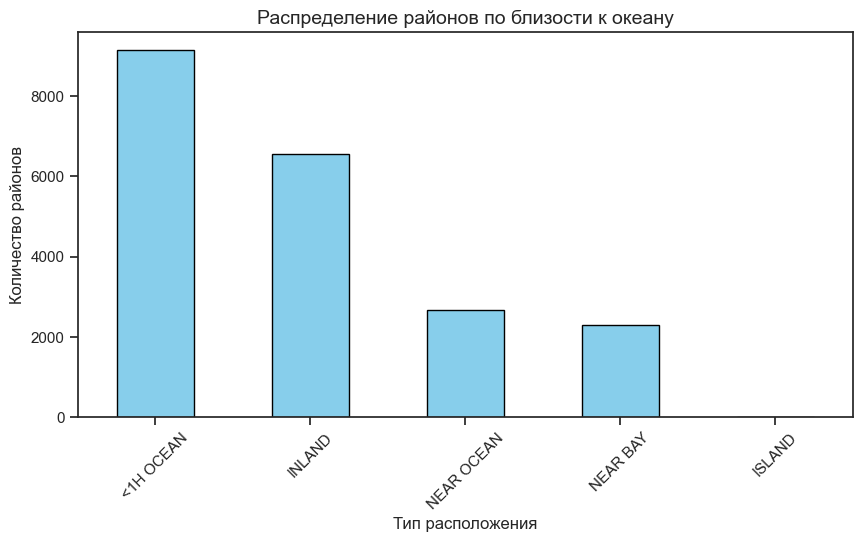

Размер данных после кодирования: (20640, 14)
Новые признаки: ['ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']
Проверка на NaN после кодирования:
207 пропусков всего


In [5]:
# Анализ категориального признака 'ocean_proximity'
print("Уникальные значения в 'ocean_proximity':")
print(df['ocean_proximity'].value_counts())

# Визуализация распределения
plt.figure(figsize=(10, 5))
df['ocean_proximity'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Распределение районов по близости к океану', fontsize=14)
plt.xlabel('Тип расположения')
plt.ylabel('Количество районов')
plt.xticks(rotation=45)
plt.show()

df = pd.get_dummies(df, columns=['ocean_proximity'], prefix='ocean', dtype=int)

# ПРОВЕРКА: убеждаемся, что нет NaN
print(f"Размер данных после кодирования: {df.shape}")
print(f"Новые признаки: {[col for col in df.columns if col.startswith('ocean_')]}")
print("Проверка на NaN после кодирования:")
print(df.isnull().sum().sum(), "пропусков всего")

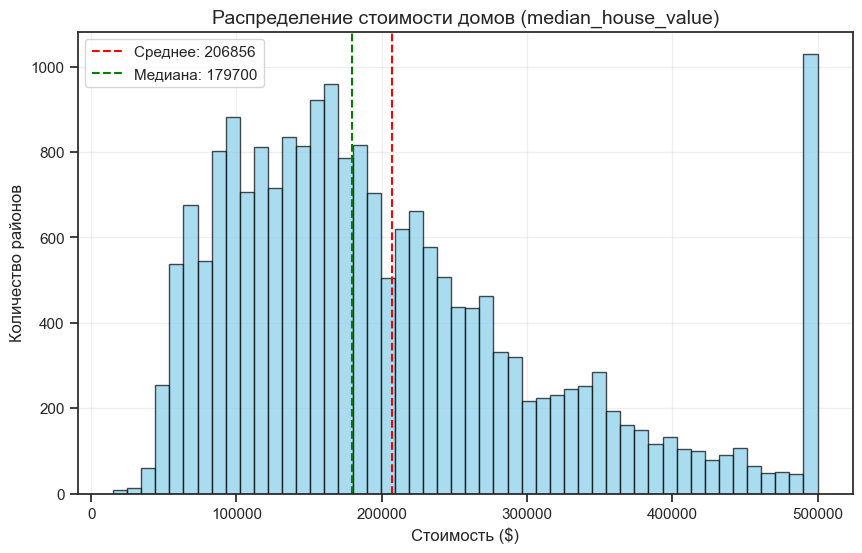

In [ ]:
# Распределение целевой переменной
plt.figure(figsize=(10, 6))
plt.hist(df['median_house_value'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Распределение стоимости домов (median_house_value)', fontsize=14)
plt.xlabel('Стоимость ($)', fontsize=12)
plt.ylabel('Количество районов', fontsize=12)
plt.axvline(df['median_house_value'].mean(), color='red', linestyle='--', 
            label=f'Среднее: {df["median_house_value"].mean():.0f}')
plt.axvline(df['median_house_value'].median(), color='green', linestyle='--', 
            label=f'Медиана: {df["median_house_value"].median():.0f}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

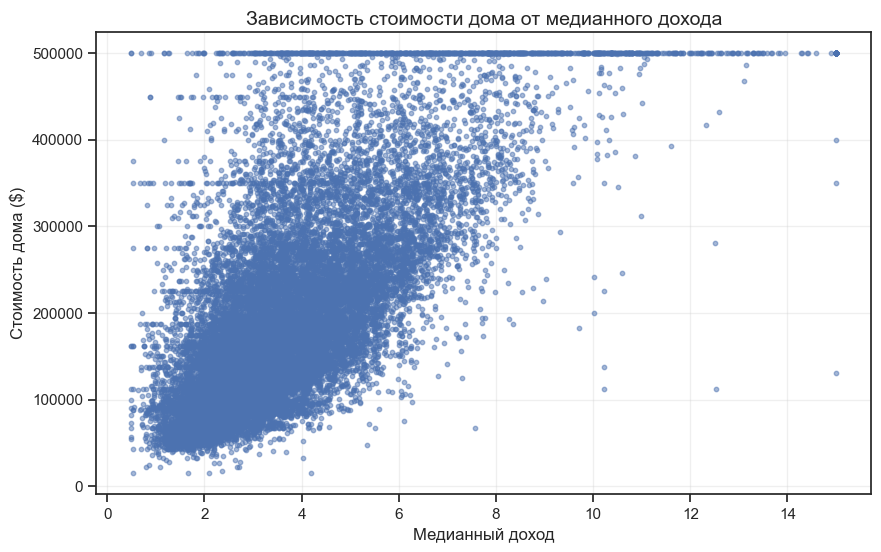

In [7]:
# Зависимость стоимости от медианного дохода
plt.figure(figsize=(10, 6))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.5, s=10)
plt.title('Зависимость стоимости дома от медианного дохода', fontsize=14)
plt.xlabel('Медианный доход', fontsize=12)
plt.ylabel('Стоимость дома ($)', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

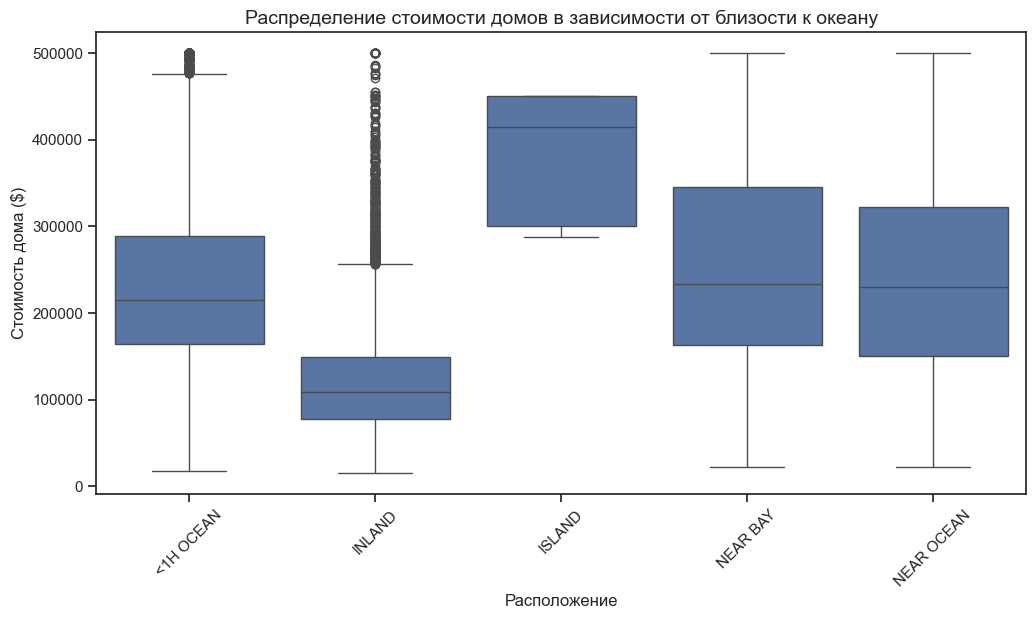

In [8]:
# Визуализация влияния расположения на стоимость
ocean_cols = [col for col in df.columns if col.startswith('ocean_')]
df_ocean_melted = pd.melt(df, id_vars=['median_house_value'], value_vars=ocean_cols, 
                           var_name='ocean_type', value_name='is_present')
df_ocean_filtered = df_ocean_melted[df_ocean_melted['is_present'] == 1]
# Очищаем названия для читаемости
df_ocean_filtered['ocean_type'] = df_ocean_filtered['ocean_type'].str.replace('ocean_', '')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_ocean_filtered, x='ocean_type', y='median_house_value')
plt.title('Распределение стоимости домов в зависимости от близости к океану', fontsize=14)
plt.xlabel('Расположение', fontsize=12)
plt.ylabel('Стоимость дома ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

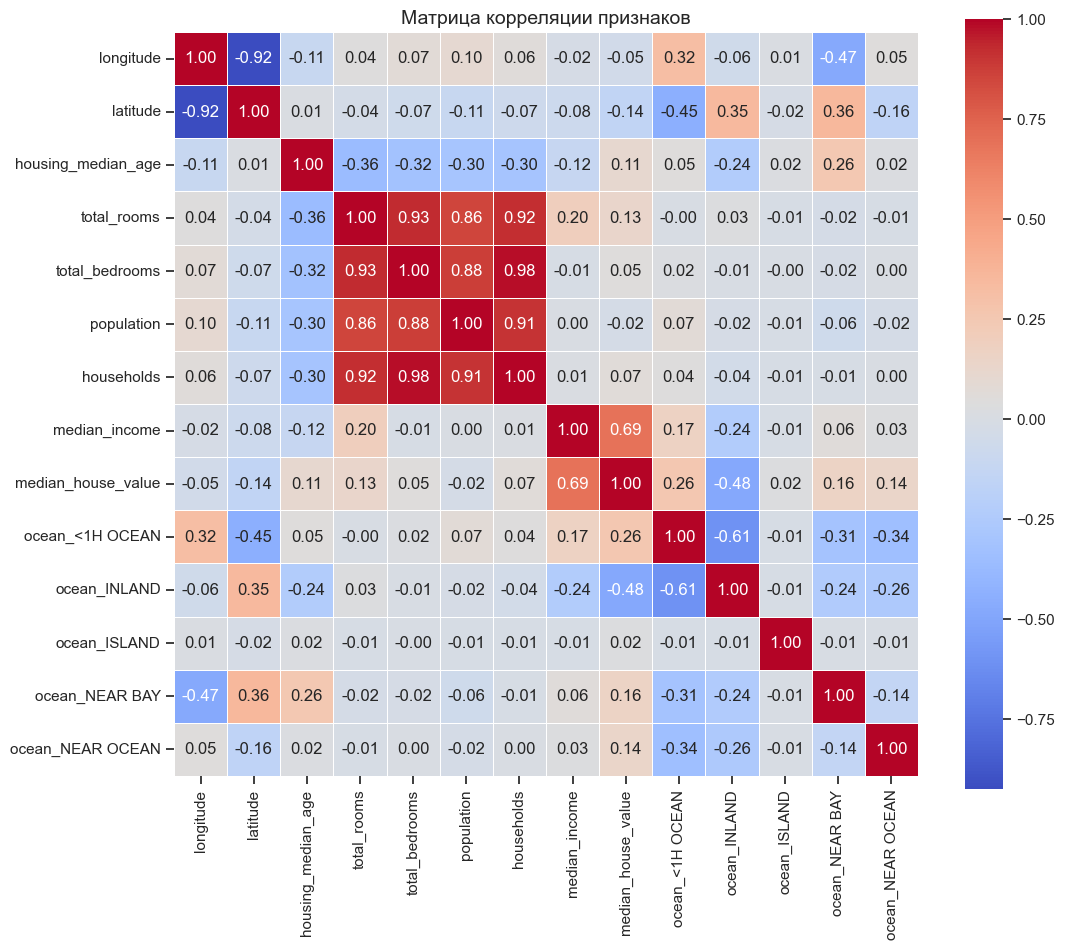

In [9]:
# Матрица корреляции
plt.figure(figsize=(12, 10))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Матрица корреляции признаков', fontsize=14)
plt.show()

In [10]:
target = 'median_house_value'

feature_cols = [col for col in df.columns if col != target]

X = df[feature_cols].copy()
y = df[target].copy()

print("Проверка пропусков перед обработкой:")
print(f"X: {X.isnull().sum().sum()} пропусков")
print(f"y: {y.isnull().sum()} пропусков")

if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("Удаляем строки с пропусками...")
    clean_data = pd.concat([X, y], axis=1)
    clean_data = clean_data.dropna()
    X = clean_data.drop(columns=[target])
    y = clean_data[target]
    print(f"После очистки: {len(X)} записей")

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Регрессия (предсказание {target})")
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"Количество признаков: {X_train.shape[1]}")

# Финальная проверка
print(f"NaN в X_train: {np.isnan(X_train).sum()}")
print(f"NaN в X_test: {np.isnan(X_test).sum()}")

Проверка пропусков перед обработкой:
X: 207 пропусков
y: 0 пропусков
Удаляем строки с пропусками...
После очистки: 20433 записей
Регрессия (предсказание median_house_value)
Обучающая выборка: (16346, 13)
Тестовая выборка: (4087, 13)
Количество признаков: 13
NaN в X_train: 0
NaN в X_test: 0


In [11]:
print("Диагностика")

# 1. Проверяем X на NaN
print(f"1. NaN в X: {X.isnull().sum().sum()}")
if X.isnull().sum().sum() > 0:
    print("Колонки с NaN:")
    print(X.columns[X.isnull().any()].tolist())

# 2. Проверяем y на NaN
print(f"2. NaN в y: {y.isnull().sum()}")

# 3. Удаляем строки с NaN если они есть (на всякий случай)
if X.isnull().sum().sum() > 0 or y.isnull().sum() > 0:
    print("Обнаружены пропуски! Удаляем строки с NaN...")
    clean_data = pd.concat([X, y], axis=1)
    clean_data = clean_data.dropna()
    X = clean_data.drop(columns=[target])
    y = clean_data[target]
    print(f"После очистки: X={X.shape}, y={y.shape}")

# 4. Финальная проверка
print(f"Итог: X NaN = {X.isnull().sum().sum()}, y NaN = {y.isnull().sum()}")
print(f"Размер выборки: {len(X)} записей")

Диагностика
1. NaN в X: 0
2. NaN в y: 0
Итог: X NaN = 0, y NaN = 0
Размер выборки: 20433 записей


In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

print("Результаты REGRESSION BASELINE")

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Model': name, 'MAE': mae, 'MSE': mse, 'R2': r2})
    print(f"{name:20} | MAE={mae:,.0f} | MSE={mse:,.0f} | R2={r2:.4f}")

baseline_df = pd.DataFrame(results)

Результаты REGRESSION BASELINE
Linear Regression    | MAE=50,413 | MSE=4,802,173,539 | R2=0.6488
KNN (k=5)            | MAE=41,213 | MSE=3,855,308,059 | R2=0.7181
Decision Tree        | MAE=42,937 | MSE=4,528,671,127 | R2=0.6688
Random Forest        | MAE=31,729 | MSE=2,375,983,209 | R2=0.8263
Gradient Boosting    | MAE=39,259 | MSE=3,198,944,435 | R2=0.7661


In [13]:
print("HYPERPARAMETER TUNING")

# Подбор для Random Forest
print("Настройка Random Forest Regressor...")
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)

print(f"Best RF Regressor params: {rf_grid.best_params_}")
print(f"Best CV R2: {rf_grid.best_score_:.4f}")

# Подбор для Gradient Boosting
print("Настройка Gradient Boosting Regressor...")
gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
gb_grid.fit(X_train, y_train)

print(f"Best GB Regressor params: {gb_grid.best_params_}")
print(f"Best CV R2: {gb_grid.best_score_:.4f}")

HYPERPARAMETER TUNING
Настройка Random Forest Regressor...
Best RF Regressor params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2: 0.8170
Настройка Gradient Boosting Regressor...
Best GB Regressor params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 150}
Best CV R2: 0.8300


In [14]:
#Сравнение
best_rf = rf_grid.best_estimator_
best_gb = gb_grid.best_estimator_

# Random Forest сравнение
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)
y_pred_rf_baseline = rf_baseline.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)

print("Random Forest: Baseline vs Tuned")
print(f"Baseline RF: MAE={mean_absolute_error(y_test, y_pred_rf_baseline):,.0f}, R2={r2_score(y_test, y_pred_rf_baseline):.4f}")
print(f"Tuned RF:    MAE={mean_absolute_error(y_test, y_pred_rf_tuned):,.0f}, R2={r2_score(y_test, y_pred_rf_tuned):.4f}")

# Gradient Boosting сравнение
gb_baseline = GradientBoostingRegressor(random_state=42)
gb_baseline.fit(X_train, y_train)
y_pred_gb_baseline = gb_baseline.predict(X_test)
y_pred_gb_tuned = best_gb.predict(X_test)

print("Gradient Boosting: Baseline vs Tuned")
print(f"Baseline GB: MAE={mean_absolute_error(y_test, y_pred_gb_baseline):,.0f}, R2={r2_score(y_test, y_pred_gb_baseline):.4f}")
print(f"Tuned GB:    MAE={mean_absolute_error(y_test, y_pred_gb_tuned):,.0f}, R2={r2_score(y_test, y_pred_gb_tuned):.4f}")

Random Forest: Baseline vs Tuned
Baseline RF: MAE=31,729, R2=0.8263
Tuned RF:    MAE=31,616, R2=0.8266
Gradient Boosting: Baseline vs Tuned
Baseline GB: MAE=39,259, R2=0.7661
Tuned GB:    MAE=31,127, R2=0.8363


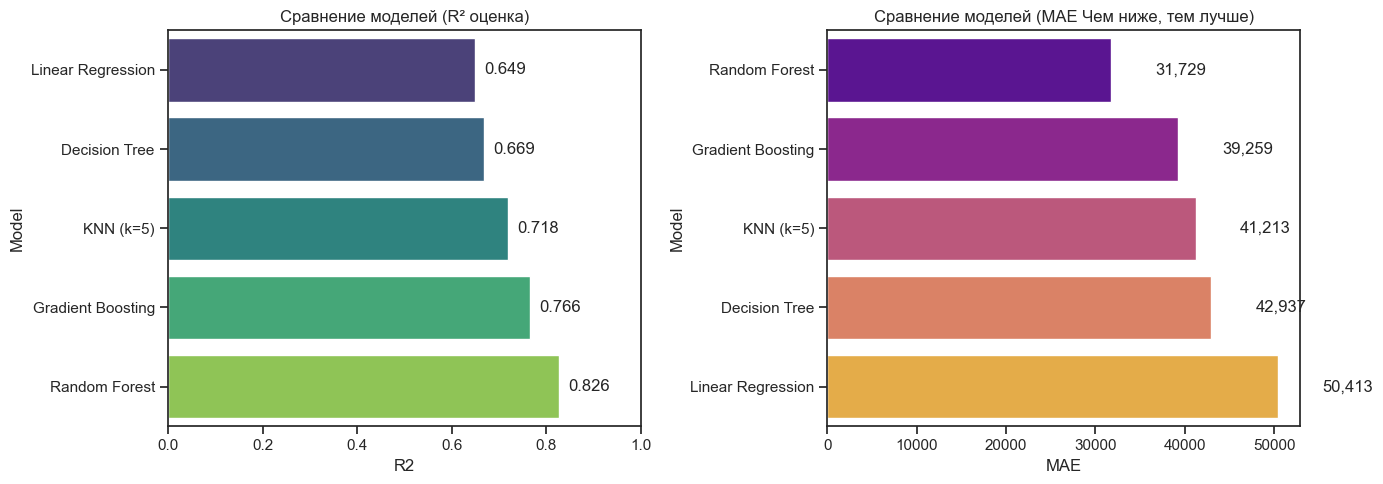

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График для R2
comparison_r2 = baseline_df.sort_values('R2', ascending=True)
sns.barplot(data=comparison_r2, x='R2', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('Сравнение моделей (R² оценка)', fontsize=12)
axes[0].set_xlim(0, 1)
for i, v in enumerate(comparison_r2['R2']):
    axes[0].text(v + 0.02, i, f'{v:.3f}', va='center')

# График для MAE
comparison_mae = baseline_df.sort_values('MAE', ascending=True)
sns.barplot(data=comparison_mae, x='MAE', y='Model', ax=axes[1], palette='plasma')
axes[1].set_title('Сравнение моделей (MAE Чем ниже, тем лучше)', fontsize=12)
for i, v in enumerate(comparison_mae['MAE']):
    axes[1].text(v + 5000, i, f'{v:,.0f}', va='center')

plt.tight_layout()
plt.show()